In [ ]:
import sys
import seaborn as sns
import pandas as pd

from paths import PathFinder
PATHS = PathFinder()

dir_s1 = PATHS["DIR_SRC"] / "out" / "study1"
ls_meta = [f for f in dir_s1.iterdir() \
    if f.suffix == '.csv' and f.name.startswith('results_')]
ls_meta

Successfully loaded /home/niche/finding_ants/.env
Available project environments: 
    DIR_iNATURALIST=/projects/niche_squad/finding-ants/inaturalist
    DIR_DATA=/projects/niche_squad/finding-ants
    DIR_DATA_FINAL=/projects/niche_squad/finding-ants/final
    DIR_DATA_ROBO=/projects/niche_squad/finding-ants/roboflow
    DIR_DATA_YOLO=/projects/niche_squad/finding-ants/yolo
    DIR_SRC=/home/niche/finding_ants
    DIR_DATA_RAW=/projects/niche_squad/finding-ants/processed


FileNotFoundError: [Errno 2] No such file or directory: '/home/niche/finding_ants/out/study1'

In [ ]:
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])
print(data.columns)
data

Index(['model', 'n_params', 'n_samples', 'thread', 'iters', 'split',
       'strategy', 'time_hptuning', 'time_inference', 'divider', 'overlap',
       'map5095', 'map50', 'precision', 'recall', 'f1', 'n_all', 'n_fn',
       'n_fp'],
      dtype='object')


,model,n_params,n_samples,thread,iters,split,strategy,time_hptuning,time_inference,divider,overlap,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp
0,yolo11n,2.6,64,5,1,test_a01,baseline,0.00,8.62,0.0,0.00,0.3526,0.8842,0.9018,0.8743,0.8878,1734,218,165
1,yolo11n,2.6,64,5,1,test_a01,bo_exploration,7.62,98.25,3.0,0.35,0.3276,0.8486,0.8382,0.8454,0.8418,1734,268,283
2,yolo11n,2.6,64,5,1,test_a01,bo_exploitation,7.21,61.48,2.0,0.21,0.3340,0.8614,0.8620,0.8679,0.8649,1734,229,241
3,yolo11n,2.6,64,5,1,test_a01,grid_search,16.39,95.09,4.0,0.25,0.3067,0.8197,0.7708,0.8397,0.8038,1734,278,433
4,yolo11n,2.6,64,5,1,test_a02,baseline,0.00,6.49,0.0,0.00,0.2080,0.6530,0.7222,0.6880,0.7047,1266,395,335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1848,rtdetr-l,45.0,1024,7,16,test_b02,grid_search,35.24,37.79,2.0,0.50,0.2503,0.6454,0.4674,0.8240,0.5964,608,107,571
1849,rtdetr-l,45.0,1024,7,16,test_b03,baseline,0.00,6.73,0.0,0.00,0.3202,0.7884,0.7669,0.7133,0.7391,143,41,31
1850,rtdetr-l,45.0,1024,7,16,test_b03,bo_exploration,12.17,75.06,2.0,0.50,0.3150,0.8475,0.8837,0.7972,0.8382,143,29,15
1851,rtdetr-l,45.0,1024,7,16,test_b03,bo_exploitation,17.21,97.19,3.0,0.27,0.3012,0.7864,0.8667,0.7273,0.7909,143,39,16


In [4]:
data.query("iters <= 6").groupby(['model', 'n_samples', 'split', "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'))

n_obs
model    n_samples split    strategy              
rtdetr-l 64        test_a01 baseline            60
                            bo_exploitation     60
                            bo_exploration      60
                            grid_search         60
                   test_a02 baseline            60
...                                            ...
yolo11n  1024      test_b02 grid_search         50
                   test_b03 baseline            50
                            bo_exploitation     50
                            bo_exploration      50
                            grid_search         50

[216 rows x 1 columns]

In [44]:
# calculate mean, median, std, min, max
data_sum = data.\
    query("iters <= 6 and strategy in ['baseline', 'grid_search']").\
    groupby(['model', 'n_samples', 'split', "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
    map_mean=pd.NamedAgg(column='map50', aggfunc='mean'),
    map_std=pd.NamedAgg(column='map50', aggfunc='std'),
    f1_mean=pd.NamedAgg(column='f1', aggfunc='mean'),
    f1_std=pd.NamedAgg(column='f1', aggfunc='std'),
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
).reset_index()
data_sum.to_csv(PATHS["DIR_SRC"] / "out" / "s1_pivot_modelwise.csv", index=False)
data_sum = data.\
    query("iters <= 6 and strategy in ['baseline', 'grid_search']").\
    groupby(['n_samples', 'split', "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
    map_mean=pd.NamedAgg(column='map50', aggfunc='mean'),
    map_std=pd.NamedAgg(column='map50', aggfunc='std'),
    f1_mean=pd.NamedAgg(column='f1', aggfunc='mean'),
    f1_std=pd.NamedAgg(column='f1', aggfunc='std'),
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
).reset_index()
data_sum.to_csv(PATHS["DIR_SRC"] / "out" / "s1_pivot_modelavg.csv", index=False)
data_sum

,n_samples,split,strategy,n_obs,map_mean,map_std,f1_mean,f1_std,pre_mean,pre_std,rec_mean,rec_std
0,64,test_a01,baseline,163,0.881856,0.072158,0.876454,0.070948,0.886733,0.072088,0.866779,0.071994
1,64,test_a01,grid_search,163,0.832018,0.097745,0.818169,0.093823,0.820064,0.108539,0.821890,0.076407
2,64,test_a02,baseline,163,0.735396,0.085339,0.756651,0.079832,0.768469,0.089644,0.747334,0.078967
3,64,test_a02,grid_search,162,0.605496,0.125956,0.644491,0.111084,0.619048,0.134112,0.688159,0.092658
4,64,test_a03,baseline,162,0.737930,0.093666,0.738585,0.086633,0.790520,0.084747,0.694519,0.092210
5,64,test_a03,grid_search,162,0.636310,0.135117,0.671223,0.113158,0.679851,0.129732,0.669084,0.103752
6,64,test_b01,baseline,162,0.598628,0.102331,0.619272,0.089765,0.652082,0.104145,0.594529,0.092403
7,64,test_b01,grid_search,162,0.498341,0.158899,0.560529,0.131709,0.547457,0.150647,0.583699,0.121121
8,64,test_b02,baseline,162,0.626506,0.117662,0.635667,0.090299,0.640714,0.130074,0.644422,0.080456
9,64,test_b02,grid_search,161,0.584948,0.136412,0.606196,0.111504,0.590278,0.143200,0.643806,0.098111


## Plotting

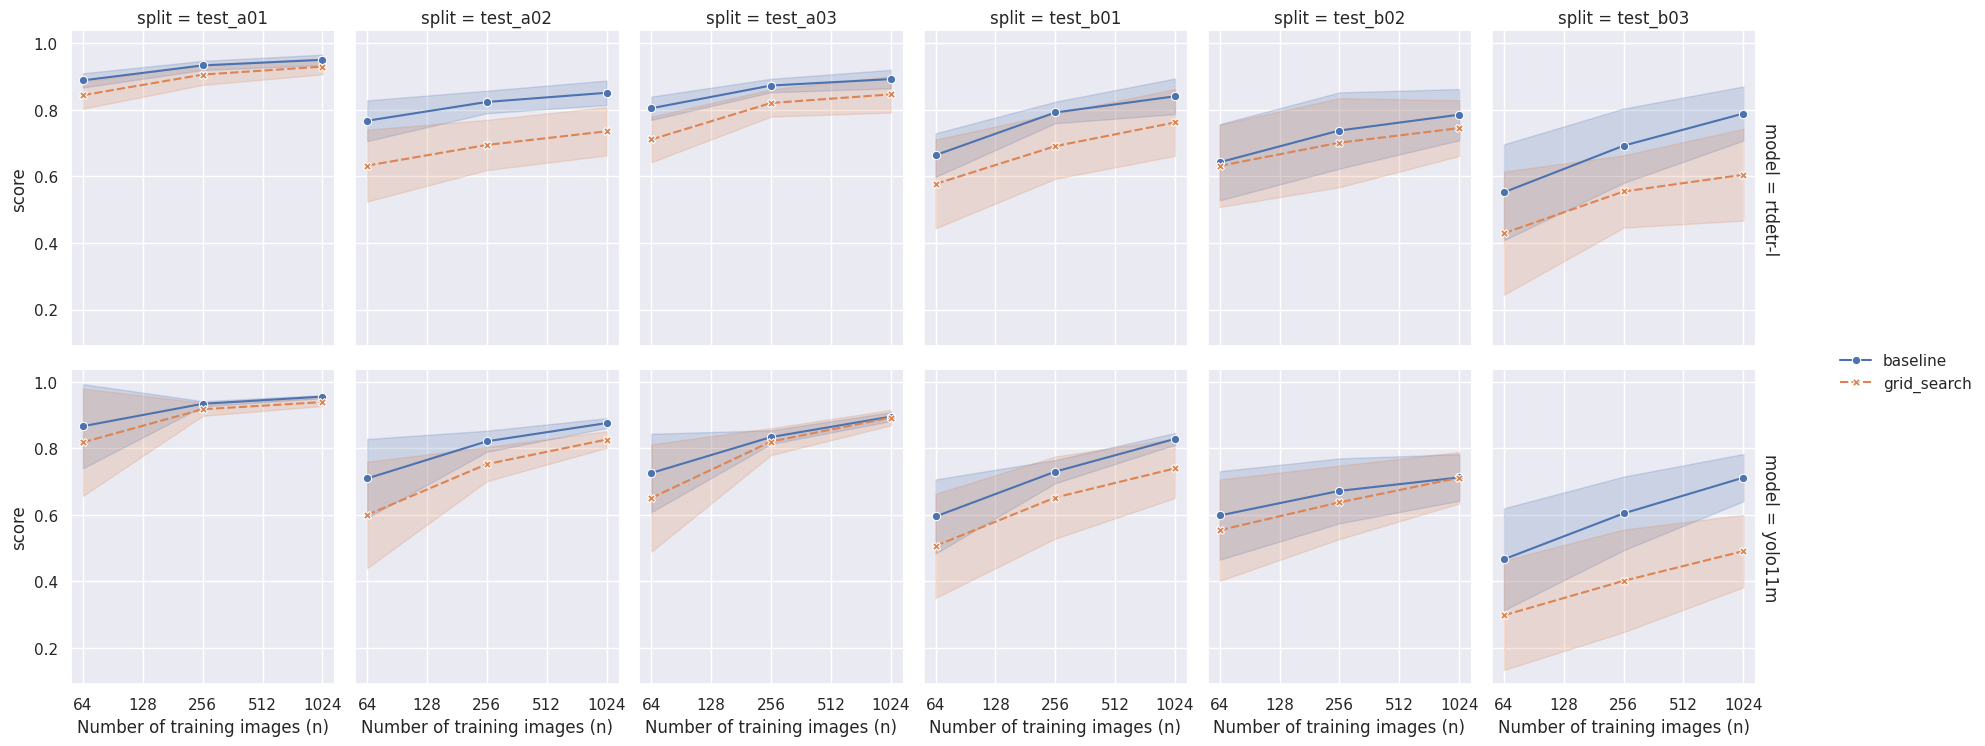

In [53]:
data_fig = data.query("iters <= 6").melt(id_vars=["model", "n_samples", "split", "strategy"], 
                     var_name="metric", value_name="score")
data_fig = data_fig.query("metric in ['precision', 'recall', 'f1', 'map50']")
data_fig["similar"] = data_fig["split"].apply(lambda x: "a" in x)

sns.set("notebook")
splits_s1 = [
    "test_a01", "test_a02", "test_a03",
    "test_b01", "test_b02", "test_b03",
            ]
strategy_order = ["baseline", 
                  "grid_search", 
                #   "bo_exploration", 
                #   "bo_exploitation",
                  ]
model_order = ["rtdetr-l", "yolo11m", ]
g = sns.FacetGrid(
    data_fig.query(f"split in {splits_s1} and metric in ['map50']"),
    row="model", col="split",
    row_order=model_order,
    margin_titles=True,
    sharey=True,
)
g.map_dataframe(sns.lineplot, 
    x="n_samples", y="score", 
    # hue="model", style="strategy",
    # hue_order=model_order,
    # style_order=strategy_order,
    hue="strategy", style="strategy",
    hue_order=strategy_order,
    style_order=strategy_order,
    err_style="band", errorbar=("sd", 1),
    markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
)
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
g.set(
    xscale="log",
    xticks=[2**i for i in range(6, 11)],
    xticklabels=[2**i for i in range(6, 11)],
    xlabel="Number of training images (n)",)
g.figure.subplots_adjust(right=1.2)
g.add_legend()
g.figure.set_size_inches(20, 8)
g.savefig(PATHS["DIR_SRC"] / "out" / "s1_results.png", dpi=300)

# save csv
data_fig.to_csv(PATHS["DIR_SRC"] / "out" / "s1_results.csv", index=False)

## Statistical examination of the difference

In [38]:
import scipy.stats as stats

def test_different(var1, var2):
    # placeholder for the outputs
    is_normal = "false"
    is_equal_var = "false"
    is_significant = "false"

    # test if the two variables are normally distributed
    _, p_var1 = stats.shapiro(var1)
    _, p_var2 = stats.shapiro(var2)
    if p_var1 > 0.05 and p_var2 > 0.05:
        is_normal = "true"
        # check if the two variables have the same variance
        _, p_var = stats.levene(var1, var2)
        if p_var > 0.05:
            is_equal_var = "true"
            # run t-test
            _, p_val = stats.ttest_ind(var1, var2, equal_var=True)
        else:
            # not the same variance
            _, p_val = stats.ttest_ind(var1, var2, equal_var=False)
    else:
        # not normal
        is_equal_var = "N/A"
        _, p_val = stats.mannwhitneyu(var1, var2)
    if p_val < 0.05:        
        if p_val < 0.001:
            is_significant = "***"
        elif p_val < 0.01:
            is_significant = "**"
        elif p_val < 0.05:
            is_significant = "*"
        # print(f"🟢 significant")
    else:
        is_significant = "ns"
        # print(f"🔴 not significant")
    
    return is_normal, is_equal_var, is_significant

In [22]:
data_fig

,model,n_samples,split,strategy,metric,score,similar
103131,yolo11n,64,test_a01,baseline,precision,0.9018,True
103132,yolo11n,64,test_a01,bo_exploration,precision,0.8382,True
103133,yolo11n,64,test_a01,bo_exploitation,precision,0.8620,True
103134,yolo11n,64,test_a01,grid_search,precision,0.7708,True
103135,yolo11n,64,test_a02,baseline,precision,0.7222,True
...,...,...,...,...,...,...,...
137503,rtdetr-l,1024,test_b02,grid_search,f1,0.7224,False
137504,rtdetr-l,1024,test_b03,baseline,f1,0.8333,False
137505,rtdetr-l,1024,test_b03,bo_exploration,f1,0.7667,False
137506,rtdetr-l,1024,test_b03,bo_exploitation,f1,0.8084,False


In [54]:
col_split = []
col_model = []
col_n = []
col_normal = []
col_equal_var = []
col_significant = []
ls_splits = data_fig["split"].unique()
ls_models = data_fig["model"].unique()
ls_n = data_fig["n_samples"].unique()
for split in ls_splits:
    for model in ls_models:
        for n in ls_n:
            # get the data for the current split, model and n
            data_tmp = data_fig.query(f"split == '{split}' and n_samples == {n} and model == '{model}' and metric == 'map50'")
            f1_baseline = data_tmp.query("strategy == 'baseline'")["score"].values
            f1_grid_search = data_tmp.query("strategy == 'grid_search'")["score"].values
            # test the two variables
            is_normal, is_equal_var, is_significant = test_different(f1_baseline, f1_grid_search)
            col_split.append(split)
            col_model.append(model)
            col_n.append(n)
            col_normal.append(is_normal)
            col_equal_var.append(is_equal_var)
            col_significant.append(is_significant)
df_results = pd.DataFrame({
    "split": col_split,
    "model": col_model,
    "n_samples": col_n,
    "is_normal": col_normal,
    "is_equal_var": col_equal_var,
    "is_significant": col_significant,
})
df_results.to_csv(PATHS["DIR_SRC"] / "out" / "s1_stats.csv", index=False)
df_results

,split,model,n_samples,is_normal,is_equal_var,is_significant
0,test_a01,yolo11n,64,false,N/A,***
1,test_a01,yolo11n,256,false,N/A,***
2,test_a01,yolo11n,1024,false,N/A,***
3,test_a01,yolo11m,64,false,N/A,***
4,test_a01,yolo11m,256,false,N/A,***
5,test_a01,yolo11m,1024,false,N/A,***
6,test_a01,rtdetr-l,64,false,N/A,***
7,test_a01,rtdetr-l,256,false,N/A,***
8,test_a01,rtdetr-l,1024,false,N/A,***
9,test_a02,yolo11n,64,false,N/A,***


## Checking interaction between model choice and strategy

In [51]:
# anova:  f1 ~ model + n_samples + split + strategy
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
model = ols('score ~ C(model) + C(strategy) + C(model):C(strategy)', 
            data=data_fig.query("metric == 'map50' and model != 'yolo11n' and strategy in ['baseline', 'grid_search']")).fit()
# t-test each slope : f1 ~ model + n_samples + split + strategy
print(model.summary())
print(anova_lm(model, typ=2))

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     93.46
Date:                Mon, 02 Jun 2025   Prob (F-statistic):           2.12e-58
Time:                        17:28:24   Log-Likelihood:                 1536.1
No. Observations:                3891   AIC:                            -3064.
Df Residuals:                    3887   BIC:                            -3039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
model = ols('score ~ C(model) + C(split) + C(model):C(split)', 
            data=data_fig.query("metric == 'map50' and model != 'yolo11n' and strategy in ['baseline', 'grid_search']")).fit()
# t-test each slope : f1 ~ model + n_samples + split + strategy
print(model.summary())
print(anova_lm(model, typ=2))

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     296.6
Date:                Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:27:44   Log-Likelihood:                 2587.9
No. Observations:                3891   AIC:                            -5152.
Df Residuals:                    3879   BIC:                            -5077.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------